In [2]:

# 1. Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder


In [6]:
# Load and clean dataset....
df = pd.read_csv('observations_mammalia_global.csv')

In [7]:
df.head(10)

,id,observed_on,local_time_observed_at,latitude,longitude,positional_accuracy,public_positional_accuracy,image_url,license,geoprivacy,taxon_geoprivacy,scientific_name,common_name,taxon_id
0,128984633,2022-08-02,2022-08-02 00:40:00+10:00,-30.490071,151.639271,11,11,https://static.inaturalist.org/photos/21914219...,NaN,NaN,open,Phascolarctos cinereus,Koala,42983
1,129048796,2022-08-02,2022-08-02 07:55:55+10:00,-38.671312,146.164746,24,24,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,NaN,open,Wallabia bicolor,Swamp Wallaby,42973
2,129051266,2022-08-02,2022-08-02 00:20:13+02:00,43.119623,-7.678884,8,8,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY,NaN,open,Plecotus auritus,Brown Big-eared Bat,40416
3,129054418,2022-08-02,2022-08-02 00:26:13+02:00,50.686439,7.169781,6,6,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,NaN,NaN,Erinaceus europaeus,Common Hedgehog,43042
4,129076855,2022-08-02,2022-08-02 13:32:23+12:00,-40.949812,174.971092,5,5,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,open,Arctocephalus forsteri,New Zealand Fur Seal,41752
5,129077332,2022-08-02,2022-08-02 13:18:00+12:00,-36.957801,174.466428,147,147,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY,NaN,open,Hydrurga leptonyx,Leopard Seal,41724
6,129078329,2022-08-02,2022-08-02 10:06:00+10:00,-36.650000,149.886678,122,28505,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,obscured,obscured,Ornithorhynchus anatinus,Platypus,43236
7,129079761,2022-08-02,2022-08-02 08:43:16+08:00,25.178586,121.794255,17,30003,https://static.inaturalist.org/photos/21931640...,NaN,NaN,obscured,Manis pentadactyla,Chinese Pangolin,43366
8,129087239,2022-08-02,2022-08-02 12:58:34+10:00,-37.405667,144.579822,249,249,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,NaN,NaN,Antechinus mimetes,Mainland Dusky Antechinus,899706
9,129090780,2022-08-02,2022-08-02 00:38:24+10:00,-30.489953,151.641020,437,437,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,NaN,open,Phascolarctos cinereus,Koala,42983


In [8]:
df['geoprivacy'].fillna('Unkown',inplace=True)

C:\Users\Mohnish\AppData\Local\Temp\ipykernel_17164\3890578628.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['geoprivacy'].fillna('Unkown',inplace=True)


In [9]:
df['license'].fillna('Unkown',inplace=True)

C:\Users\Mohnish\AppData\Local\Temp\ipykernel_17164\4081355247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['license'].fillna('Unkown',inplace=True)


In [10]:
# Use 'scientific_name' as species column
df_clean = df[['scientific_name', 'latitude', 'longitude']].dropna()

In [11]:
df

,id,observed_on,local_time_observed_at,latitude,longitude,positional_accuracy,public_positional_accuracy,image_url,license,geoprivacy,taxon_geoprivacy,scientific_name,common_name,taxon_id
0,128984633,2022-08-02,2022-08-02 00:40:00+10:00,-30.490071,151.639271,11,11,https://static.inaturalist.org/photos/21914219...,Unkown,Unkown,open,Phascolarctos cinereus,Koala,42983
1,129048796,2022-08-02,2022-08-02 07:55:55+10:00,-38.671312,146.164746,24,24,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,Unkown,open,Wallabia bicolor,Swamp Wallaby,42973
2,129051266,2022-08-02,2022-08-02 00:20:13+02:00,43.119623,-7.678884,8,8,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY,Unkown,open,Plecotus auritus,Brown Big-eared Bat,40416
3,129054418,2022-08-02,2022-08-02 00:26:13+02:00,50.686439,7.169781,6,6,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,Unkown,NaN,Erinaceus europaeus,Common Hedgehog,43042
4,129076855,2022-08-02,2022-08-02 13:32:23+12:00,-40.949812,174.971092,5,5,https://inaturalist-open-data.s3.amazonaws.com...,Unkown,Unkown,open,Arctocephalus forsteri,New Zealand Fur Seal,41752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1648189,148898888,2010-10-20,2010-10-20 11:41:00-02:00,-22.451339,-42.771501,8,8,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,Unkown,open,Bradypus variegatus,Brown-throated Three-toed Sloth,47067
1648190,148899694,2010-10-20,2010-10-20 14:36:00-02:00,-22.449795,-42.772553,8,8,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,Unkown,open,Hydrochoerus hydrochaeris,Capybara,74442
1648191,148899948,2011-10-28,2011-10-28 14:35:00+02:00,50.986605,6.982738,177,177,https://static.inaturalist.org/photos/25649773...,Unkown,Unkown,open,Sciurus vulgaris,Eurasian Red Squirrel,46001
1648192,148900694,2014-08-16,2014-08-16 11:00:00+02:00,-13.086323,31.786098,61,61,https://inaturalist-open-data.s3.amazonaws.com...,CC-BY-NC,Unkown,open,Tragelaphus strepsiceros strepsiceros,Kudu,524159


In [12]:
# Optional: encode species for plotting or ML
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['species_encoded'] = le.fit_transform(df_clean['scientific_name'])

In [13]:
# ================================
# NEW STEP: Reduce number of classes
# ================================

top_n = 50   # you can keep 30–50

top_species = df_clean['scientific_name'].value_counts().head(top_n).index

df_filtered = df_clean[df_clean['scientific_name'].isin(top_species)]

print("Filtered dataset shape:", df_filtered.shape)
print("Number of species:", df_filtered['scientific_name'].nunique())

Filtered dataset shape: (1041021, 4)
Number of species: 50


In [14]:
# Quick check
print(df_clean.head())
print("Number of unique species:", df_clean['scientific_name'].nunique())

          scientific_name   latitude   longitude  species_encoded
0  Phascolarctos cinereus -30.490071  151.639271             3313
1        Wallabia bicolor -38.671312  146.164746             4738
2        Plecotus auritus  43.119623   -7.678884             3420
3     Erinaceus europaeus  50.686439    7.169781             1239
4  Arctocephalus forsteri -40.949812  174.971092              199
Number of unique species: 4770


C:\Users\Mohnish\AppData\Local\Temp\ipykernel_17164\2109708680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_species.values, y=top_species.index, palette="viridis")


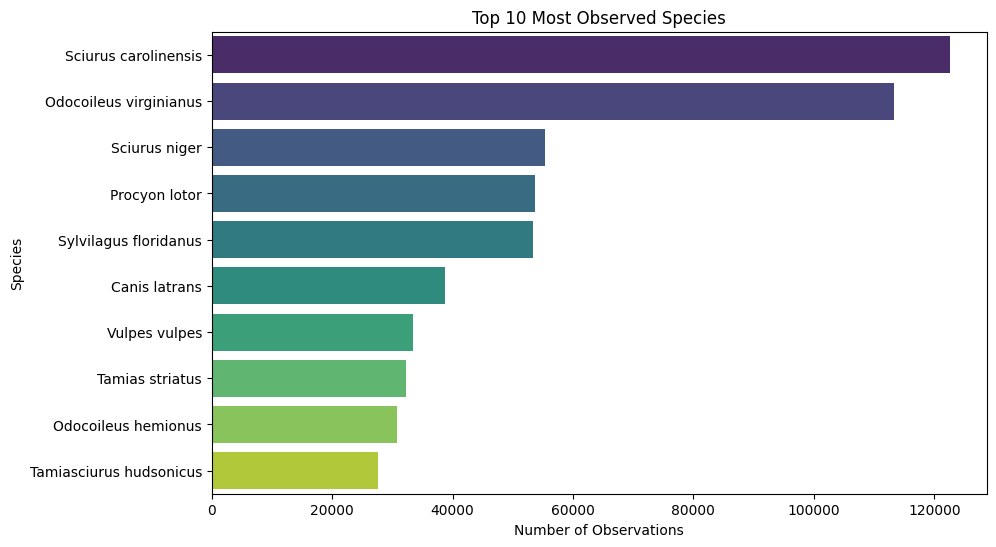

In [15]:
# Top 10 Most Observed Species (Bar Chart)
top_species = df_clean['scientific_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_species.values, y=top_species.index, palette="viridis")
plt.title("Top 10 Most Observed Species")
plt.xlabel("Number of Observations")
plt.ylabel("Species")
plt.savefig("top_10_species.jpg", dpi=300, bbox_inches='tight')
plt.show()


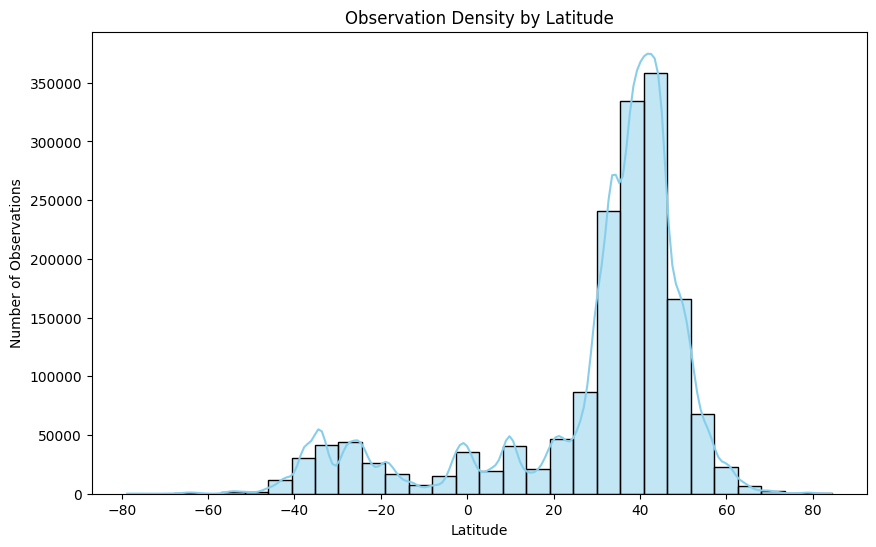

In [16]:
# Observation Density by Latitude (Histogram)
plt.figure(figsize=(10,6))
sns.histplot(df_clean['latitude'], bins=30, kde=True, color='skyblue')
plt.title("Observation Density by Latitude")
plt.xlabel("Latitude")
plt.ylabel("Number of Observations")
plt.savefig("latitude_density.jpg", dpi=300, bbox_inches='tight')
plt.show()


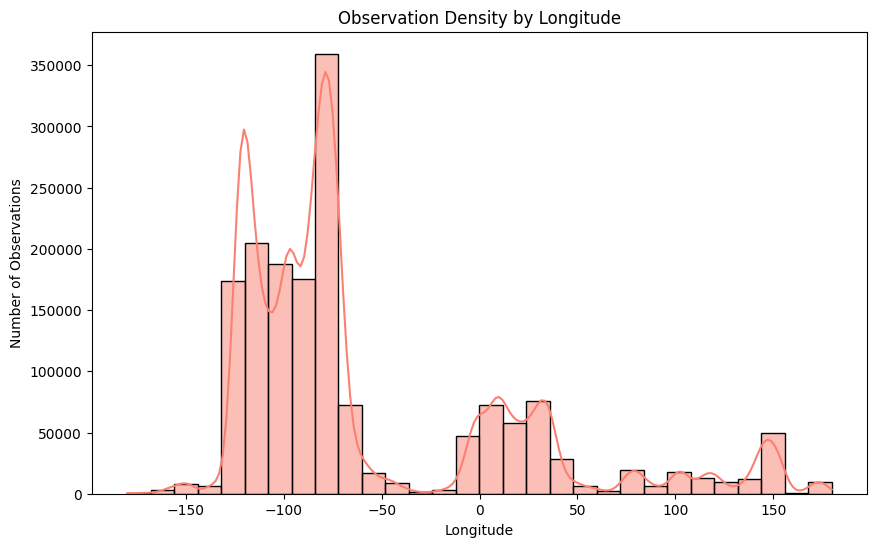

In [17]:
# 3. Observation Density by Longitude (Histogram)
plt.figure(figsize=(10,6))
sns.histplot(df_clean['longitude'], bins=30, kde=True, color='salmon')
plt.title("Observation Density by Longitude")
plt.xlabel("Longitude")
plt.ylabel("Number of Observations")
plt.savefig("longitude_density.jpg", dpi=300, bbox_inches='tight')
plt.show()


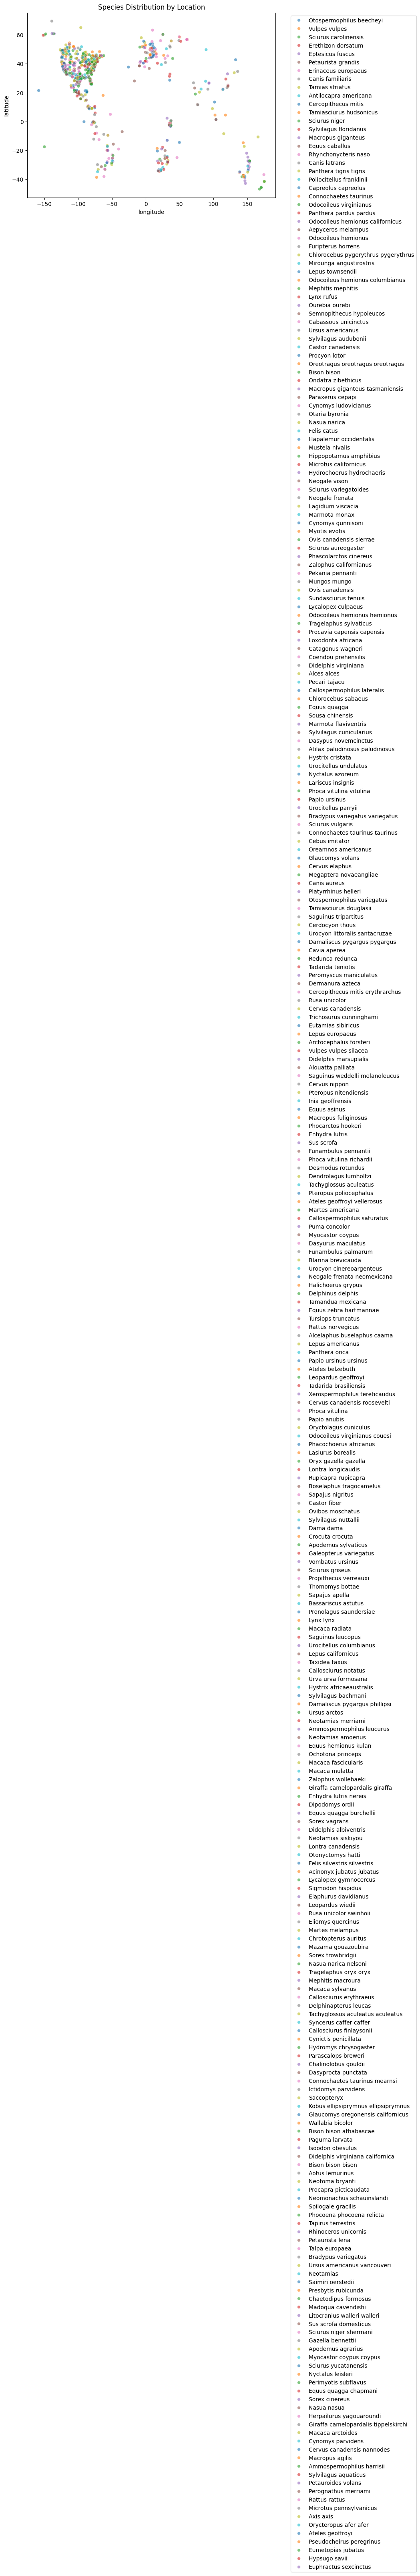

In [18]:
# 4. Species Distribution Map (Scatter Plot)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="scientific_name",
    data=df_clean.sample(min(1000, len(df_clean))),
    alpha=0.6,
    s=30,
    palette="tab10"
)
plt.title("Species Distribution by Location")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("species_distribution.jpg", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\Mohnish\AppData\Local\Temp\ipykernel_17164\1226712592.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_heat.groupby(['lat_bin','lon_bin']).size().unstack(fill_value=0)


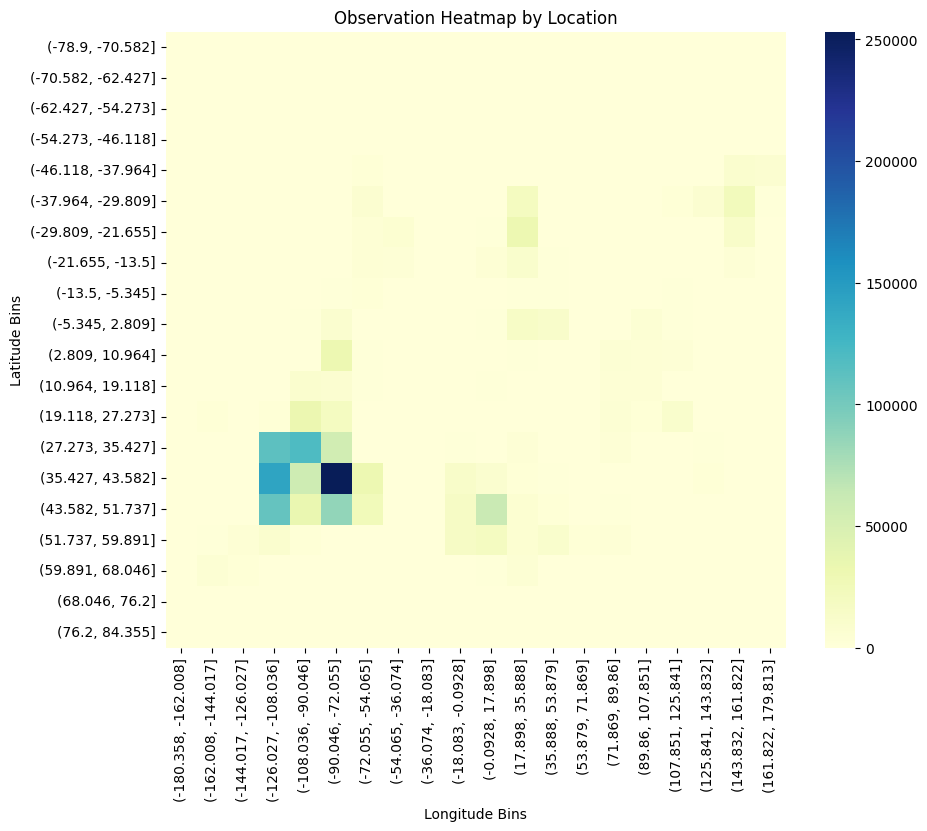

In [19]:
# 5. Species Observation Heatmap (Optional)
df_heat = df_clean.copy()
df_heat['lat_bin'] = pd.cut(df_heat['latitude'], bins=20)
df_heat['lon_bin'] = pd.cut(df_heat['longitude'], bins=20)
heatmap_data = df_heat.groupby(['lat_bin','lon_bin']).size().unstack(fill_value=0)

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Observation Heatmap by Location")
plt.xlabel("Longitude Bins")
plt.ylabel("Latitude Bins")
plt.savefig("observation_heatmap.jpg", dpi=300, bbox_inches='tight')
plt.show()


In [20]:
# ================================
#  Feature Selection
# ================================

X = df_filtered[['latitude', 'longitude']]
y = df_filtered['species_encoded']


# ================================
# Scaling (IMPORTANT for SVM)
# ================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")

Feature scaling completed


In [21]:
# ================================
#  Train-Test Split (Fixed)
# ================================

from sklearn.model_selection import train_test_split

# Remove rare classes (less than 2 samples)
import pandas as pd

class_counts = pd.Series(y).value_counts()
valid_classes = class_counts[class_counts > 1].index

mask = pd.Series(y).isin(valid_classes)

X_filtered = X_scaled[mask]
y_filtered = y[mask]

# Now split safely
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (832816, 2)
Test shape: (208205, 2)


In [22]:
# ================================
#  Sampling for SVM (FIXED)
# ================================

sample_size = 10000   # reduced from 50000

X_train_svm = X_train[:sample_size]
y_train_svm = y_train[:sample_size]

X_test_svm = X_test[:3000]
y_test_svm = y_test[:3000]

print("SVM Train shape:", X_train_svm.shape)
print("SVM Test shape:", X_test_svm.shape)

SVM Train shape: (10000, 2)
SVM Test shape: (3000, 2)


In [23]:
# ================================
#  Support Vector Machine (FAST)
# ================================

from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=2000)

svm_model.fit(X_train_svm, y_train_svm)

svm_pred = svm_model.predict(X_test_svm)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


In [24]:
# ================================
# . Linear Regression (Comparison)
# ================================

from sklearn.linear_model import LinearRegression
import numpy as np

lin_model = LinearRegression()

lin_model.fit(X_train_svm, y_train_svm)

# Convert regression output → classification
lin_pred = np.round(lin_model.predict(X_test_svm)).astype(int)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [25]:
# ================================
#  Model Evaluation
# ================================

from sklearn.metrics import accuracy_score

# Random Forest (your existing model)
# print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

# SVM
print("SVM Accuracy:", accuracy_score(y_test_svm, svm_pred))

# Linear Regression
print("Linear Regression Accuracy:", accuracy_score(y_test_svm, lin_pred))

SVM Accuracy: 0.14033333333333334
Linear Regression Accuracy: 0.0006666666666666666


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1648194 entries, 0 to 1648193
Data columns (total 14 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1648194 non-null  int64  
 1   observed_on                 1648194 non-null  object 
 2   local_time_observed_at      1648194 non-null  object 
 3   latitude                    1648194 non-null  float64
 4   longitude                   1648194 non-null  float64
 5   positional_accuracy         1648194 non-null  int64  
 6   public_positional_accuracy  1648194 non-null  int64  
 7   image_url                   1644210 non-null  object 
 8   license                     1648194 non-null  object 
 9   geoprivacy                  1648194 non-null  object 
 10  taxon_geoprivacy            1511664 non-null  object 
 11  scientific_name             1648194 non-null  object 
 12  common_name                 1645843 non-null  object 
 1

In [27]:
# ================================
# Sampling for Random Forest
# ================================

rf_sample_size = 200000   # adjust if needed (100k–300k)
X_test_rf = X_test[:70000]
y_test_rf = y_test[:70000] 

X_train_rf = X_train[:rf_sample_size]
y_train_rf = y_train[:rf_sample_size]

print("RF Train shape:", X_train_rf.shape)

RF Train shape: (200000, 2)


In [28]:
# ================================
# Random Forest (Lightweight)
# ================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=20,     # smaller forest
    max_depth=10,        # shallow trees
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

rf_pred = rf_model.predict(X_test_rf)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [29]:
print("Random Forest Accuracy:", accuracy_score(y_test_rf, rf_pred))

Random Forest Accuracy: 0.3341142857142857


In [30]:
# improve performance for randomforest

rf_model = RandomForestClassifier(
    n_estimators=50,      # increase trees
    max_depth=20,         # deeper trees
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

rf_pred = rf_model.predict(X_test_rf)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [31]:
print("Random Forest Accuracy:", accuracy_score(y_test_rf, rf_pred))

Random Forest Accuracy: 0.41185714285714287


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1648194 entries, 0 to 1648193
Data columns (total 14 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1648194 non-null  int64  
 1   observed_on                 1648194 non-null  object 
 2   local_time_observed_at      1648194 non-null  object 
 3   latitude                    1648194 non-null  float64
 4   longitude                   1648194 non-null  float64
 5   positional_accuracy         1648194 non-null  int64  
 6   public_positional_accuracy  1648194 non-null  int64  
 7   image_url                   1644210 non-null  object 
 8   license                     1648194 non-null  object 
 9   geoprivacy                  1648194 non-null  object 
 10  taxon_geoprivacy            1511664 non-null  object 
 11  scientific_name             1648194 non-null  object 
 12  common_name                 1645843 non-null  object 
 1

In [33]:
# ================================
# Save Random Forest Model
# ================================

import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [34]:
# ================================
# Save Scaler
# ================================

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!
